In [ ]:
import pandas as pd
!gdown 1XfIzY_WcfLzKr0asxKXQpQZmCd2aWtfy
df = pd.read_csv('/content/topic_modeling_data.csv')

Downloading...
From: https://drive.google.com/uc?id=1XfIzY_WcfLzKr0asxKXQpQZmCd2aWtfy
To: /content/topic_modeling_data.csv
100% 4.29M/4.29M [00:00<00:00, 49.3MB/s]


In [ ]:
# # Cài đặt thư viện (Chạy 1 lần)
# !pip install bertopic
# !pip install sentence-transformers

# # Import các thư viện cần thiết
# from bertopic import BERTopic
# import pandas as pd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.4 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


# BERT

### EMBEDDINGS - Tùy chỉnh

In [ ]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

# 1. Cấu hình N-gram (từ 1 đến 3 chữ) để đặt tên Topic chuyên nghiệp hơn
# Chúng ta đưa danh sách stopwords vào đây để loại bỏ từ vô nghĩa khi hiện kết quả
vectorizer_model = CountVectorizer(ngram_range=(1, 3), stop_words=None)

# 2. Khởi tạo mô hình
topic_model = BERTopic(
    language="multilingual",
    vectorizer_model=vectorizer_model, # Sử dụng N-gram ở đây
    min_topic_size=10,
    verbose=True
)

# 3. Huấn luyện với cột clean_text
docs = df['clean_text'].tolist()
topics, probs = topic_model.fit_transform(docs)

# 4. Xuất kết quả
topic_info = topic_model.get_topic_info()
topic_info['Representative_Docs'] = topic_info['Representative_Docs'].apply(lambda x: [d[:100] + "..." for d in x])
print("=== BẢNG THÔNG TIN CHỦ ĐỀ ===")
display(topic_info)

2025-12-23 09:48:08,574 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/97 [00:00<?, ?it/s]

2025-12-23 09:51:20,881 - BERTopic - Embedding - Completed ✓
2025-12-23 09:51:20,883 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-23 09:51:42,871 - BERTopic - Dimensionality - Completed ✓
2025-12-23 09:51:42,873 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-23 09:51:43,019 - BERTopic - Cluster - Completed ✓
2025-12-23 09:51:43,024 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-23 09:51:43,955 - BERTopic - Representation - Completed ✓


=== BẢNG THÔNG TIN CHỦ ĐỀ ===


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1489,-1_công_ty_nhân_viên_lương_công_việc,"[công_ty, nhân_viên, lương, công_việc, làm_việ...",[thòi thời_gian làm_việc thay_đổi liên_tục hiệ...
1,0,242,0_phỏng_vấn_công_ty_lắm_văn_phòng,"[phỏng_vấn, công_ty, lắm, văn_phòng, nghỉ, sợ,...",[bây_giờ chúng_ta chăm_sóc da trò_chơi cạnh xo...
2,1,227,1_lương_nhân_viên_công_ty_tr,"[lương, nhân_viên, công_ty, tr, tiền, nghỉ, là...",[công_ty đề_nghị vị_trí ví_dụ tr khuyên làm_vi...
3,2,158,2_công_ty_nhân_viên_quản_lý_lương,"[công_ty, nhân_viên, quản_lý, lương, tiền, ca,...",[công_ty mafia hàn quốc_gia_đình lý tương lịch...
4,3,99,3_học_trẻ_công_việc_kinh_nghiệm,"[học, trẻ, công_việc, kinh_nghiệm, nhân_viên, ...",[ceo học tào học cướp học_đòi kiến_thức chuyên...
5,4,80,4_marketing_kinh_nghiệm_ngành_vị_trí,"[marketing, kinh_nghiệm, ngành, vị_trí, hồ_sơ,...",[phỏng_vấn vị_trí marketing nói_chung digital ...
6,5,73,5_quản_lý_bó_công_ty_tiếng,"[quản_lý, bó, công_ty, tiếng, đồng, kiến_thức,...",[mãi_mãi toàn môi_trường toxic drama nịnh_bợ k...
7,6,60,6_công_ty_phỏng_vấn_end_thất_nghiệp,"[công_ty, phỏng_vấn, end, thất_nghiệp, kinh_ng...",[vía tỷ_lệ anh_em thời lạnh hôm_nay nộp đơn xo...
8,7,48,7_tips_khuyên_công_sở_trải,"[tips, khuyên, công_sở, trải, trải nghiệm, ngh...",[chủ_đề tips công_sở có_thể đời_sống chia bill...
9,8,45,8_đồng_nghiệp_đồng_công_ty_bắc,"[đồng_nghiệp, đồng, công_ty, bắc, văn_phòng bắ...",[tự_nhiên hồi xưa học ông_bà chắt_chiu đồng gử...


In [ ]:
# # --- BƯỚC 1: LẤY EMBEDDINGS ---
# # Nếu bạn chưa có biến embeddings, ta dùng hàm này để trích xuất lại từ model và dữ liệu docs
# print("⏳ Đang trích xuất embeddings từ dữ liệu (có thể mất vài phút)...")
# embeddings = topic_model._extract_embeddings(df['clean_text'].tolist(), method="document")

In [ ]:
# import numpy as np

# # Lưu ma trận embeddings vào file
# np.save('hr_embeddings.npy', embeddings)
# print("✅ Đã lưu embeddings thành công vào file 'hr_embeddings.npy'!")

In [ ]:
import numpy as np

# --- BƯỚC 1: LOAD EMBEDDINGS TỪ FILE ---
print("⏳ Đang tải embeddings từ file (vèo một cái là xong)...")

try:
    embeddings = np.load('hr_embeddings.npy')
    print(f"✅ Đã load xong! Kích thước ma trận: {embeddings.shape}")
except FileNotFoundError:
    print("❌ Không tìm thấy file! Bạn cần chạy lại cell trích xuất một lần để tạo file đã.")

# Bây giờ bạn có thể thoải mái chạy các cell Tune ở dưới mà không sợ mất thời gian nữa.

⏳ Đang tải embeddings từ file (vèo một cái là xong)...
✅ Đã load xong! Kích thước ma trận: (3085, 384)


### Kết quả đơn thuần

In [ ]:
from sklearn.metrics.pairwise import cosine_distances
import numpy as np

# Giả sử bạn vừa chạy nén topic xong: topic_model.reduce_topics(docs, nr_topics=10)

# CẬP NHẬT: Lấy nhãn mới nhất từ model
current_labels = topic_model.topics_

# --- BƯỚC 2: CHUẨN BỊ DỮ LIỆU ---
# Dùng current_labels thay vì topics
valid_indices = [i for i, t in enumerate(current_labels) if t != -1]
valid_embeddings = embeddings[valid_indices]
valid_topics = np.array(current_labels)[valid_indices]
unique_labels = sorted(list(set(valid_topics)))

# --- BƯỚC 3: TÍNH TÂM CỤM ---
centroids = []
for label in unique_labels:
    cluster_embeddings = valid_embeddings[valid_topics == label]
    centroids.append(np.mean(cluster_embeddings, axis=0))
centroids = np.array(centroids)

# --- BƯỚC 4: TÍNH COMPACTNESS ---
intra_distances = []
for i, label in enumerate(unique_labels):
    cluster_embeddings = valid_embeddings[valid_topics == label]
    dist_to_centroid = cosine_distances(cluster_embeddings, centroids[i].reshape(1, -1))
    intra_distances.append(np.mean(dist_to_centroid))

compactness = np.mean(intra_distances)

# --- BƯỚC 5: TÍNH SEPARATION ---
inter_distances = cosine_distances(centroids)
separation = np.mean(inter_distances[np.triu_indices(len(unique_labels), k=1)])

print(f"📊 Kết quả cho {len(unique_labels)} topics:")
print(f"🔹 Compactness: {compactness:.4f}")
print(f"🔹 Separation:  {separation:.4f}")

📊 Kết quả cho 36 topics:
🔹 Compactness: 0.1393
🔹 Separation:  0.2868


In [ ]:
# Lưu mô hình vào thư viện
topic_model.save("bertopic_model_after_outliers", serialization="safetensors", save_ctfidf=True)


In [ ]:
#load model
from bertopic import BERTopic
# Tải lại mô hình
topic_model = BERTopic.load("bertopic_model_after_outliers")

# Tune cụm

📸 Đang tạo bản sao lưu (Snapshot) của mô hình gốc...
⏳ Đang bắt đầu quá trình Tune (Sử dụng Deep Copy)...


2025-12-23 09:51:51,455 - BERTopic - Topic reduction - Reducing number of topics
2025-12-23 09:51:51,491 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-23 09:51:52,479 - BERTopic - Representation - Completed ✓
2025-12-23 09:51:52,487 - BERTopic - Topic reduction - Reduced number of topics from 37 to 31
2025-12-23 09:51:54,576 - BERTopic - Topic reduction - Reducing number of topics
2025-12-23 09:51:54,589 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-23 09:51:55,561 - BERTopic - Representation - Completed ✓
2025-12-23 09:51:55,568 - BERTopic - Topic reduction - Reduced number of topics from 37 to 26
2025-12-23 09:51:57,437 - BERTopic - Topic reduction - Reducing number of topics
2025-12-23 09:51:57,450 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-23 09:51:58,404 - BERTopic - Representation - Completed ✓
2025-12-23 09:51:58,409 - BERTopic - Topic reduction - Reduced nu

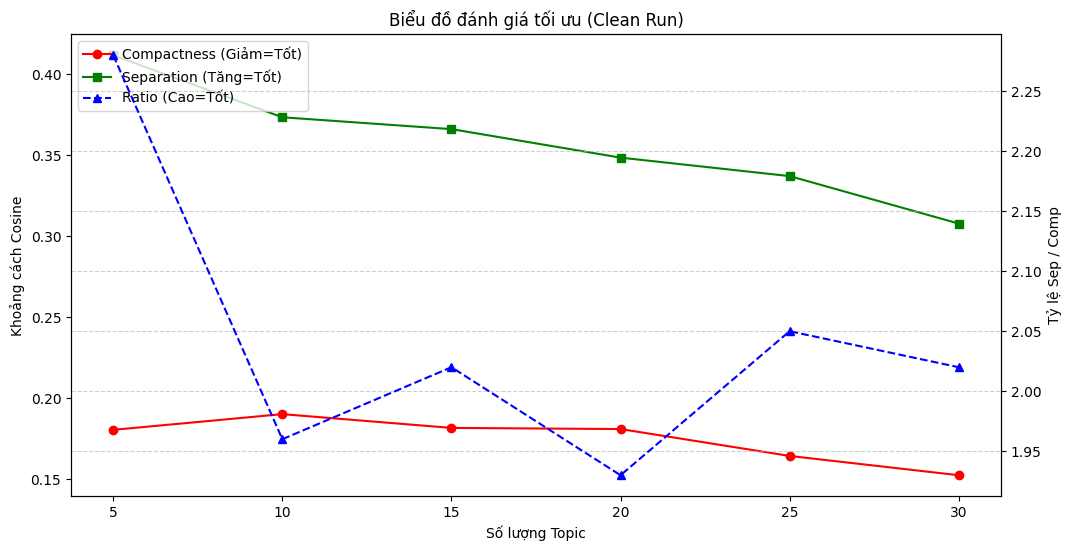

,Nr_Topics,Compactness,Separation,Ratio
5,5,0.1803,0.4115,2.28
4,10,0.1900,0.3732,1.96
3,15,0.1815,0.3659,2.02
2,20,0.1808,0.3483,1.93
1,25,0.1642,0.3369,2.05
0,30,0.1523,0.3076,2.02


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy # <--- Thư viện quan trọng để sao chép mô hình
from sklearn.metrics.pairwise import cosine_distances

# --- HÀM TÍNH CHỈ SỐ (Giữ nguyên) ---
def get_metrics(current_embeddings, current_topics):
    valid_idx = [i for i, t in enumerate(current_topics) if t != -1]
    if len(valid_idx) == 0: return 0, 0

    v_emb = current_embeddings[valid_idx]
    v_top = np.array(current_topics)[valid_idx]
    u_labels = sorted(list(set(v_top)))

    # 1. Centroids
    centroids = np.array([np.mean(v_emb[v_top == l], axis=0) for l in u_labels])

    # 2. Compactness
    comp_list = [np.mean(cosine_distances(v_emb[v_top == l], centroids[i].reshape(1, -1)))
                 for i, l in enumerate(u_labels)]
    avg_comp = np.mean(comp_list)

    # 3. Separation
    if len(u_labels) > 1:
        inter_dist = cosine_distances(centroids)
        avg_sep = np.mean(inter_dist[np.triu_indices(len(u_labels), k=1)])
    else:
        avg_sep = 0
    return round(avg_comp, 4), round(avg_sep, 4)

# --- CHUẨN BỊ ---
docs_list = df['clean_text'].tolist()

# ⚠️ QUAN TRỌNG: Đảm bảo model đang ở trạng thái gốc (40 topics) trước khi chạy dòng dưới
# Nếu model đang bị lỗi, hãy load lại từ file:
# topic_model = BERTopic.load("bertopic_model_after_outliers")

print("📸 Đang tạo bản sao lưu (Snapshot) của mô hình gốc...")
# Tạo một bản sao 'bất tử' trong RAM. Chúng ta sẽ không bao giờ chạm vào biến này.
master_topic_model = copy.deepcopy(topic_model)

results = []
print("⏳ Đang bắt đầu quá trình Tune (Sử dụng Deep Copy)...")

# --- VÒNG LẶP TUNE AN TOÀN ---
for n in range(31, 5, -5): # Chạy từ 39 xuống 5
    try:
        # 1. CLONE: Tạo ra một bản nháp từ bản gốc
        # Mỗi lần lặp là một object mới tinh, không dính líu gì đến lần trước
        temp_model = copy.deepcopy(master_topic_model)

        # 2. NÉN TRỰC TIẾP TRÊN BẢN NHÁP
        # Vì là bản mới tinh từ gốc nên nén rất mượt, không lỗi KeyError
        temp_model.reduce_topics(docs_list, nr_topics=n)

        # 3. TÍNH TOÁN
        current_topics = temp_model.topics_
        actual_nr_topics = len(set(current_topics)) - (1 if -1 in current_topics else 0)

        comp, sep = get_metrics(embeddings, current_topics)
        ratio = round(sep/comp, 2) if comp != 0 else 0

        results.append({
            "Nr_Topics": actual_nr_topics,
            "Compactness": comp,
            "Separation": sep,
            "Ratio": ratio
        })

        if n % 5 == 0:
            print(f"✅ Đã nén bản nháp về {actual_nr_topics} topics | Ratio: {ratio}")

        # Xóa bản nháp để giải phóng RAM cho vòng lặp sau
        del temp_model

    except Exception as e:
        print(f"⚠️ Lỗi ở mốc {n}: {e}")

# --- VẼ BIỂU ĐỒ ---
df_res = pd.DataFrame(results).sort_values("Nr_Topics")

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Số lượng Topic')
ax1.set_ylabel('Khoảng cách Cosine')
line1 = ax1.plot(df_res['Nr_Topics'], df_res['Compactness'], marker='o', label='Compactness (Giảm=Tốt)', color='red')
line2 = ax1.plot(df_res['Nr_Topics'], df_res['Separation'], marker='s', label='Separation (Tăng=Tốt)', color='green')

ax2 = ax1.twinx()
ax2.set_ylabel('Tỷ lệ Sep / Comp')
line3 = ax2.plot(df_res['Nr_Topics'], df_res['Ratio'], marker='^', label='Ratio (Cao=Tốt)', color='blue', linestyle='--')

lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Biểu đồ đánh giá tối ưu (Clean Run)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

display(df_res)

# Chọn model 1 - chưa loại topci -1. Chỉ số oke

In [ ]:
from bertopic import BERTopic
# Tải lại mô hình
topic_model = BERTopic.load("bertopic_model_after_outliers")
# Ví dụ bạn chọn n = 15 sau khi xem bảng
topic_model.reduce_topics(df['clean_text'].tolist(), nr_topics=6)

# Sau đó bạn có thể Visualize hoặc lấy Caption sạch
info_final = topic_model.get_topic_info()
display(info_final)

2025-12-23 09:52:43,893 - BERTopic - Topic reduction - Reducing number of topics
2025-12-23 09:52:43,906 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-23 09:52:44,891 - BERTopic - Representation - Completed ✓
2025-12-23 09:52:44,898 - BERTopic - Topic reduction - Reduced number of topics from 37 to 6


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1489,-1_công_ty_nhân_viên_lương_công_việc,"[công_ty, nhân_viên, lương, công_việc, làm_việ...",[công_ty gia_đình tổng_giám_đốc phó_giám_đốc q...
1,0,1517,0_lương_công_ty_nhân_viên_công_việc,"[lương, công_ty, nhân_viên, công_việc, làm_việ...",[mẹ nợ lương nợ bảo_hiểm nợ tiền đầu_tư tư thằ...
2,1,31,1_facebook_video_tiktok_youtube,"[facebook, video, tiktok, youtube, tập, sir, m...",[podcast hạt_giống tương_lai xanh tập tích_hợp...
3,2,21,2_lương_chậm_nhân_sự_nhân_viên,"[lương, chậm, nhân_sự, nhân_viên, chậm lương, ...",[lập danh_mục nhân_sự tự_ý lương tất_cả nhân_v...
4,3,16,3_laptop_văn_phòng_mua_công_ty,"[laptop, văn_phòng, mua, công_ty, sử_dụng, dân...",[tình_hình anni mua ny nam quà liên_quan công_...
5,4,11,4_boss_nhiệm_vụ_manager_nói_chuyện,"[boss, nhiệm_vụ, manager, nói_chuyện, nhân_viê...",[lời_nói thân_thương boss yêu trình_độ bây_giờ...


# Visulization model 1

In [ ]:
!pip install gensim
!pip install wordcloud

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_distances

# --- BƯỚC 1: ĐỒNG BỘ DỮ LIỆU ---
# Đảm bảo dùng đúng docs mà bạn đã dùng cho new_topics và embeddings
current_labels = np.array(topic_model.topics_)
unique_labels = sorted([l for l in set(current_labels) if l != -1])

# Lấy bảng thông tin topic hiện tại để tra cứu tên
df_info = topic_model.get_topic_info()

topic_metrics = []

# --- BƯỚC 2: TÍNH TOÁN ---
# Chỉ tính cho các nhãn đang THỰC SỰ tồn tại trong model
for label in unique_labels:
    # Lấy các vector thuộc cụm này
    idx = np.where(current_labels == label)[0]
    cluster_embeddings = embeddings[idx]

    # Tính Tâm cụm
    centroid = np.mean(cluster_embeddings, axis=0).reshape(1, -1)

    # 1. Compactness: Khoảng cách TB từ các điểm đến tâm
    dist_to_centroid = cosine_distances(cluster_embeddings, centroid)
    comp_i = np.mean(dist_to_centroid)

    # 2. Lấy tên Topic an toàn
    name_row = df_info[df_info['Topic'] == label]
    topic_name = name_row['Name'].values[0] if not name_row.empty else f"Topic {label}"

    topic_metrics.append({
        "Topic_ID": label,
        "Topic_Name": topic_name,
        "Compactness": round(comp_i, 4),
        "Size": len(idx)
    })

# --- BƯỚC 3: TÍNH SEPARATION ---
# (Tính giữa các tâm cụm đang hiện có)
all_centroids = np.array([np.mean(embeddings[current_labels == l], axis=0) for l in unique_labels])
if len(unique_labels) > 1:
    inter_dist_matrix = cosine_distances(all_centroids)
    # Tính Separation cho từng topic (TB khoảng cách đến các topic khác)
    for i, m in enumerate(topic_metrics):
        sep_i = np.mean([dist for j, dist in enumerate(inter_dist_matrix[i]) if i != j])
        m["Separation"] = round(sep_i, 4)
else:
    for m in topic_metrics: m["Separation"] = 0

# Hiển thị kết quả
df_final_metrics = pd.DataFrame(topic_metrics)
display(df_final_metrics)

print(f"\n✅ Trung bình Compactness: {df_final_metrics['Compactness'].mean():.4f}")
print(f"✅ Trung bình Separation:  {df_final_metrics['Separation'].mean():.4f}")

,Topic_ID,Topic_Name,Compactness,Size,Separation
0,0,0_lương_công_ty_nhân_viên_công_việc,0.2566,1517,0.3042
1,1,1_facebook_video_tiktok_youtube,0.2395,31,0.4604
2,2,2_lương_chậm_nhân_sự_nhân_viên,0.1308,21,0.4626
3,3,3_laptop_văn_phòng_mua_công_ty,0.1433,16,0.4384
4,4,4_boss_nhiệm_vụ_manager_nói_chuyện,0.1311,11,0.3918



✅ Trung bình Compactness: 0.1803
✅ Trung bình Separation:  0.4115


In [ ]:
topic_model.visualize_topics()

In [ ]:
topic_model.visualize_hierarchy()

In [ ]:
topic_model.visualize_barchart(top_n_topics=10)

📸 Đang hiển thị WordCloud cho 6 chủ đề...


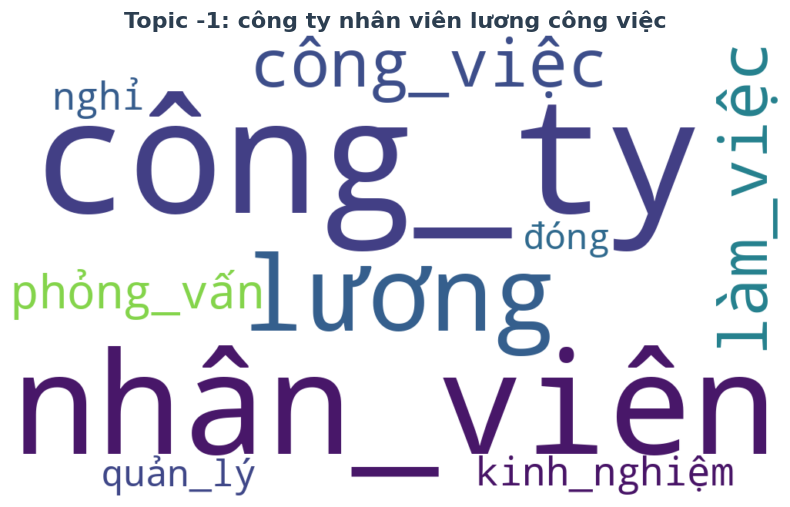

--------------------------------------------------


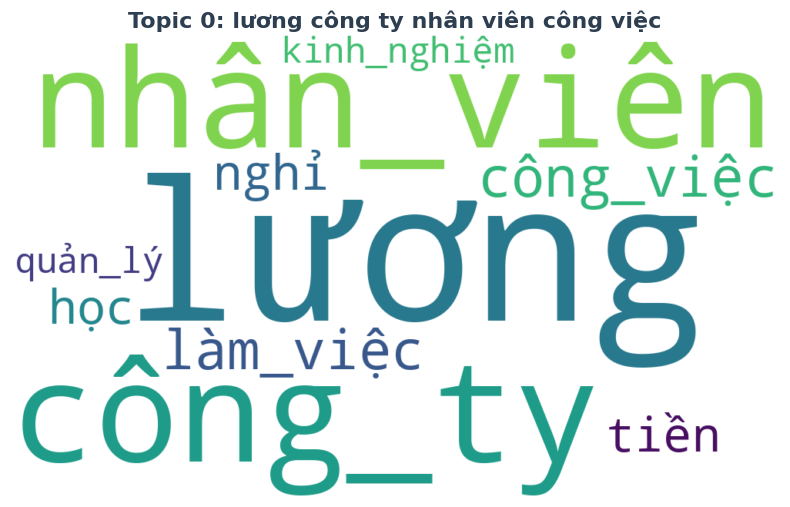

--------------------------------------------------


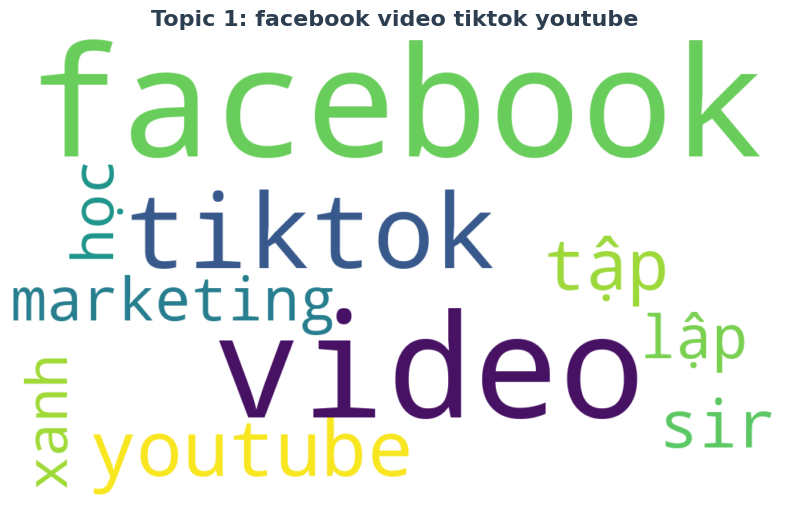

--------------------------------------------------


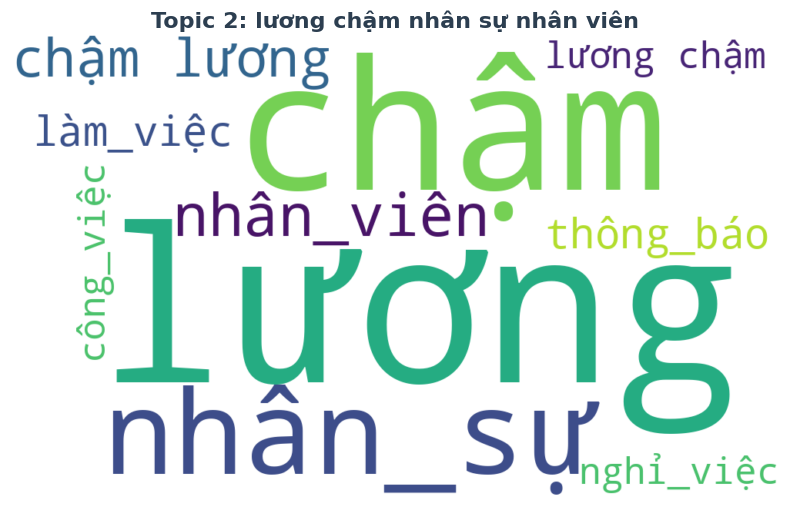

--------------------------------------------------


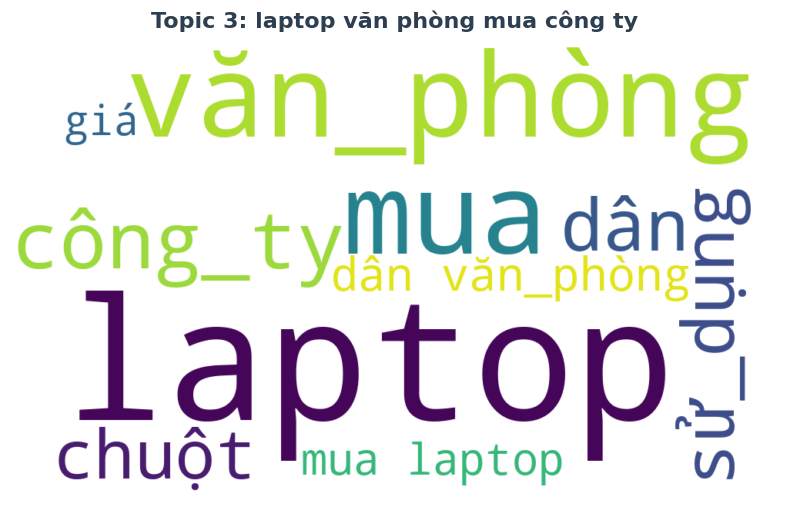

--------------------------------------------------


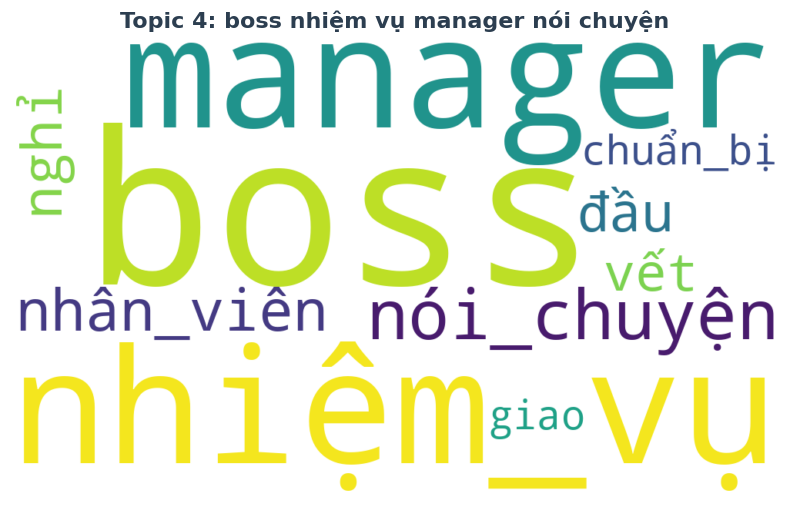

--------------------------------------------------


In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import os



# --- BƯỚC 2: LẤY DANH SÁCH TOPIC ---
# Lấy danh sách ID các topic (loại bỏ topic -1 nếu muốn)
all_topics = sorted([t for t in set(topic_model.topics_)])

# Giới hạn số lượng nếu quá nhiều (Ví dụ chỉ hiện 10 topic đầu)
# Bỏ dòng này nếu muốn hiện hết
display_topics = all_topics[:10]

print(f"📸 Đang hiển thị WordCloud cho {len(display_topics)} chủ đề...")

# --- BƯỚC 3: HIỂN THỊ TỪNG HÌNH ---
for topic_id in display_topics:
    # 1. Lấy dữ liệu từ model
    topic_data = topic_model.get_topic(topic_id)
    if not topic_data: continue # Bỏ qua nếu lỗi

    words_dict = {word: prob for word, prob in topic_data}

    # 2. Tạo WordCloud
    wc = WordCloud(
        background_color="white",
        width=1000,          # Tăng kích thước ảnh cho nét
        height=600,
        max_words=50,        # Số lượng từ hiển thị
        colormap='viridis'   # Màu sắc
    )
    wc.generate_from_frequencies(words_dict)

    # 3. Lấy tên Topic làm tiêu đề
    info = topic_model.get_topic_info(topic_id)
    topic_name = info['Name'].values[0]
    # Làm sạch tên (bỏ số ID ở đầu, ví dụ "0_lương_thưởng" -> "lương_thưởng")
    clean_name = " ".join(topic_name.split("_")[1:])

    # 4. Vẽ hình riêng biệt
    plt.figure(figsize=(10, 6)) # Tạo khung hình mới cho mỗi vòng lặp
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Topic {topic_id}: {clean_name}", fontsize=16, fontweight='bold', color='#2c3e50')
    plt.show() # <--- Quan trọng: Lệnh này khiến hình hiện ra ngay lập tức rồi mới qua hình sau

    print("-" * 50) # Đường kẻ ngăn cách giữa các hình

# Model 2 - Reduce OUTLIERS nhưng chỉ số giảm

In [ ]:
# Sau khi chạy fit_transform xong, bạn chạy thêm dòng này:
new_topics = topic_model.reduce_outliers(df['clean_text'].tolist(), topic_model.topics_, strategy="c-tf-idf")

# Cập nhật lại model với nhãn mới
topic_model.update_topics(df['clean_text'].tolist(), topics=new_topics)
info = topic_model.get_topic_info()
display(info)

2025-12-23 09:53:10,883 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


,Topic,Count,Name,Representation,Representative_Docs
0,0,2933,0_lương_công_ty_nhân_viên_công_việc,"[lương, công_ty, nhân_viên, công_việc, làm_việ...",[mẹ nợ lương nợ bảo_hiểm nợ tiền đầu_tư tư thằ...
1,1,40,1_facebook_video_tiktok_youtube,"[facebook, video, tiktok, youtube, theseedofgr...",[podcast hạt_giống tương_lai xanh tập tích_hợp...
2,2,50,2_lương_chậm_nhân_sự_nhân_viên,"[lương, chậm, nhân_sự, nhân_viên, thông_báo, n...",[lập danh_mục nhân_sự tự_ý lương tất_cả nhân_v...
3,3,43,3_văn_phòng_dân_laptop_mua,"[văn_phòng, dân, laptop, mua, giá, sử_dụng, ch...",[tình_hình anni mua ny nam quà liên_quan công_...
4,4,19,4_nhiệm_vụ_boss_manager_giao,"[nhiệm_vụ, boss, manager, giao, nói_chuyện, ch...",[lời_nói thân_thương boss yêu trình_độ bây_giờ...


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_distances

# --- BƯỚC 1: ĐỒNG BỘ DỮ LIỆU ---
# Đảm bảo dùng đúng docs mà bạn đã dùng cho new_topics và embeddings
current_labels = np.array(topic_model.topics_)
unique_labels = sorted([l for l in set(current_labels) if l != -1])

# Lấy bảng thông tin topic hiện tại để tra cứu tên
df_info = topic_model.get_topic_info()

topic_metrics = []

# --- BƯỚC 2: TÍNH TOÁN ---
# Chỉ tính cho các nhãn đang THỰC SỰ tồn tại trong model
for label in unique_labels:
    # Lấy các vector thuộc cụm này
    idx = np.where(current_labels == label)[0]
    cluster_embeddings = embeddings[idx]

    # Tính Tâm cụm
    centroid = np.mean(cluster_embeddings, axis=0).reshape(1, -1)

    # 1. Compactness: Khoảng cách TB từ các điểm đến tâm
    dist_to_centroid = cosine_distances(cluster_embeddings, centroid)
    comp_i = np.mean(dist_to_centroid)

    # 2. Lấy tên Topic an toàn
    name_row = df_info[df_info['Topic'] == label]
    topic_name = name_row['Name'].values[0] if not name_row.empty else f"Topic {label}"

    topic_metrics.append({
        "Topic_ID": label,
        "Topic_Name": topic_name,
        "Compactness": round(comp_i, 4),
        "Size": len(idx)
    })

# --- BƯỚC 3: TÍNH SEPARATION ---
# (Tính giữa các tâm cụm đang hiện có)
all_centroids = np.array([np.mean(embeddings[current_labels == l], axis=0) for l in unique_labels])
if len(unique_labels) > 1:
    inter_dist_matrix = cosine_distances(all_centroids)
    # Tính Separation cho từng topic (TB khoảng cách đến các topic khác)
    for i, m in enumerate(topic_metrics):
        sep_i = np.mean([dist for j, dist in enumerate(inter_dist_matrix[i]) if i != j])
        m["Separation"] = round(sep_i, 4)
else:
    for m in topic_metrics: m["Separation"] = 0

# Hiển thị kết quả
df_final_metrics = pd.DataFrame(topic_metrics)
display(df_final_metrics)

print(f"\n✅ Trung bình Compactness: {df_final_metrics['Compactness'].mean():.4f}")
print(f"✅ Trung bình Separation:  {df_final_metrics['Separation'].mean():.4f}")

,Topic_ID,Topic_Name,Compactness,Size,Separation
0,0,0_lương_công_ty_nhân_viên_công_việc,0.2380,2933,0.1498
1,1,1_facebook_video_tiktok_youtube,0.2702,40,0.2929
2,2,2_lương_chậm_nhân_sự_nhân_viên,0.2324,50,0.2250
3,3,3_văn_phòng_dân_laptop_mua,0.2812,43,0.1935
4,4,4_nhiệm_vụ_boss_manager_giao,0.2031,19,0.2455



✅ Trung bình Compactness: 0.2450
✅ Trung bình Separation:  0.2213


# Visualize Model 2

In [ ]:
topic_model.visualize_topics()

In [ ]:
topic_model.visualize_hierarchy()

In [ ]:
topic_model.visualize_barchart(top_n_topics=10)

📸 Đang hiển thị WordCloud cho 5 chủ đề...


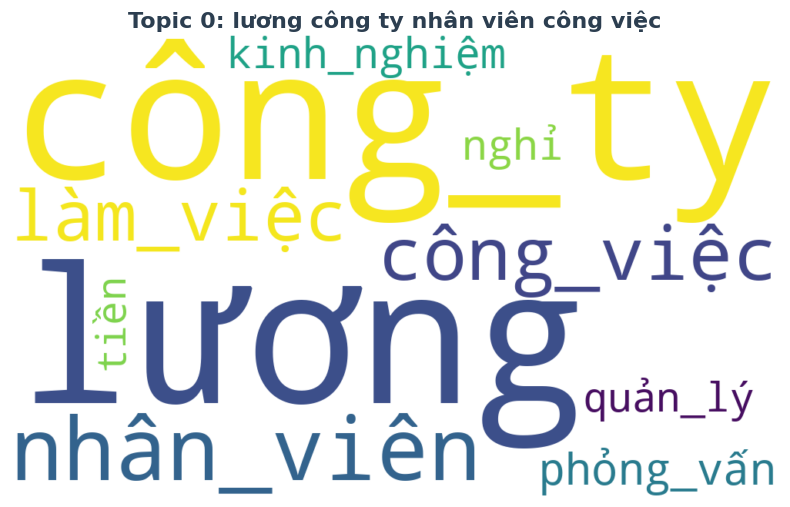

--------------------------------------------------


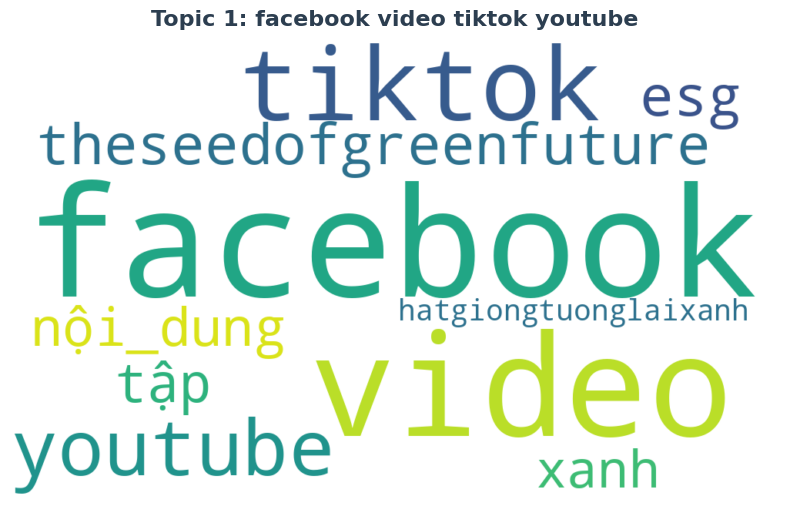

--------------------------------------------------


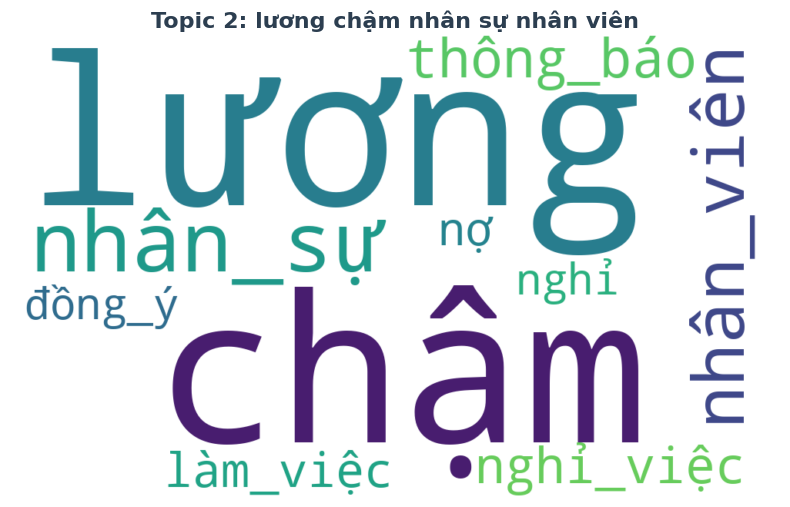

--------------------------------------------------


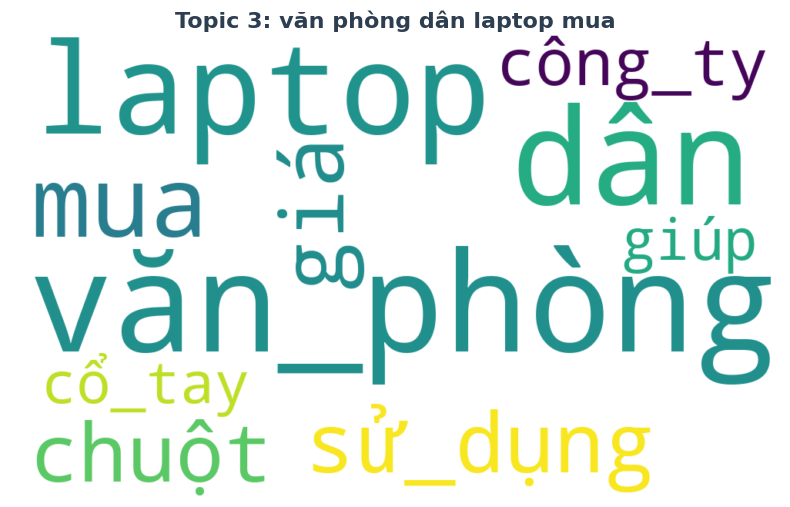

--------------------------------------------------


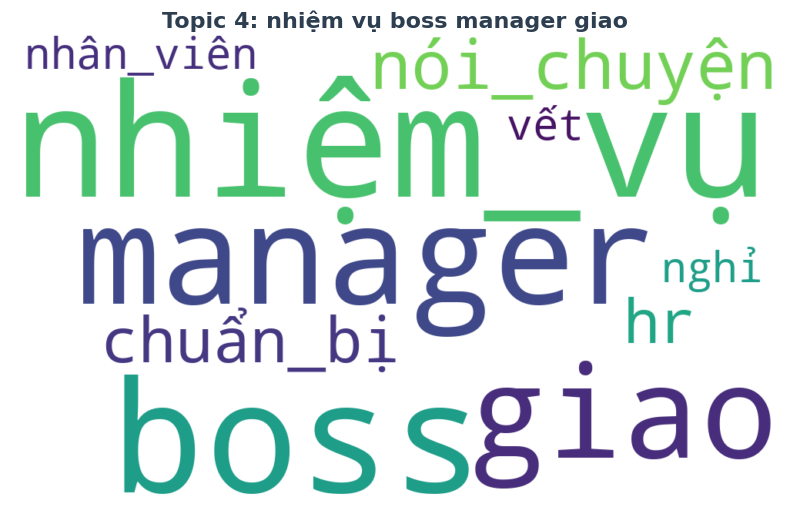

--------------------------------------------------


In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import os



# --- BƯỚC 2: LẤY DANH SÁCH TOPIC ---
# Lấy danh sách ID các topic (loại bỏ topic -1 nếu muốn)
all_topics = sorted([t for t in set(topic_model.topics_)])

# Giới hạn số lượng nếu quá nhiều (Ví dụ chỉ hiện 10 topic đầu)
# Bỏ dòng này nếu muốn hiện hết
display_topics = all_topics[:10]

print(f"📸 Đang hiển thị WordCloud cho {len(display_topics)} chủ đề...")

# --- BƯỚC 3: HIỂN THỊ TỪNG HÌNH ---
for topic_id in display_topics:
    # 1. Lấy dữ liệu từ model
    topic_data = topic_model.get_topic(topic_id)
    if not topic_data: continue # Bỏ qua nếu lỗi

    words_dict = {word: prob for word, prob in topic_data}

    # 2. Tạo WordCloud
    wc = WordCloud(
        background_color="white",
        width=1000,          # Tăng kích thước ảnh cho nét
        height=600,
        max_words=50,        # Số lượng từ hiển thị
        colormap='viridis'   # Màu sắc
    )
    wc.generate_from_frequencies(words_dict)

    # 3. Lấy tên Topic làm tiêu đề
    info = topic_model.get_topic_info(topic_id)
    topic_name = info['Name'].values[0]
    # Làm sạch tên (bỏ số ID ở đầu, ví dụ "0_lương_thưởng" -> "lương_thưởng")
    clean_name = " ".join(topic_name.split("_")[1:])

    # 4. Vẽ hình riêng biệt
    plt.figure(figsize=(10, 6)) # Tạo khung hình mới cho mỗi vòng lặp
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Topic {topic_id}: {clean_name}", fontsize=16, fontweight='bold', color='#2c3e50')
    plt.show() # <--- Quan trọng: Lệnh này khiến hình hiện ra ngay lập tức rồi mới qua hình sau

    print("-" * 50) # Đường kẻ ngăn cách giữa các hình